In [2]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import json
import numpy as np
import math
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.svm import SVC 
# Példa adathalmaz (45 videó, mindegyikben 25 frame, 25 kulcspont, 2 adat)


In [3]:
input_files = [
    "bent-over_rows",
    "biceps",
    "latheral_raises",
    "rdl",
    "shoulder_press",
    "squat"
]


In [4]:
def calculateFrameVectors(json_file, frame_idx):
    frame1 = json_file['frames'][frame_idx]
    frame2 = json_file['frames'][frame_idx+1]

    #a két kép közötti kulcspontokból csinál vektorokat
    frameDatas=[]

    for i in range(len(frame1['keypoints'])):
        vector=[]
        # vector.append(frame1['keypoints'][i]['x'])
        # vector.append(frame1['keypoints'][i]['y'])
        

        vector.append(frame2['keypoints'][i]['x']- frame1['keypoints'][i]['x'])
        vector.append(frame2['keypoints'][i]['y']- frame1['keypoints'][i]['y'])
        # vector.append(frame2['keypoints'][i]['depth']- frame1['keypoints'][i]['depth'])
        
        frameDatas.append(vector)
    return frameDatas

In [5]:
base_path = r"C:\Users\Legion\Documents\Projektmunka\DepthBasics-WPF\bin\Debug\frames"
data= []
Y_train=[]

X_test=[]
Y_test=[]

for file_name in input_files:  # Fájlnév iteráció
    file_folder_path = os.path.join(base_path, file_name)

    contents= os.listdir(file_folder_path)

    trainingSize=0.2*len(contents)


    for i in range(len(contents)): 


        file_path = os.path.join(file_folder_path, contents[i])

        with open(file_path, "r") as f:
            

            json_file=json.load(f)
            movement=[]


            for frame_idx in range(len(json_file['frames'])-1): 
                frameDatas=calculateFrameVectors(json_file, frame_idx)
                movement.append(frameDatas)
                if(len(movement)==25):  
                    if i<trainingSize :
                        X_test.append(movement)  
                        Y_test.append(json_file['video_name'])
                        movement=[]
                    else :
                        data.append(movement)
                        Y_train.append(json_file['video_name'])
                        movement=[]

X_train= np.array(data)
Y_train= np.array(Y_train)
X_test= np.array(X_test)
Y_test = np.array(Y_test)


print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test .shape)

(217, 25, 25, 2)
(217,)
(67, 25, 25, 2)
(67,)


In [6]:
from sklearn.model_selection import GridSearchCV

 # Minden videónak egy címke (0 vagy 1)

# 1. Laposítás (frame-eket külön mintákba rendezünk)

X_train= X_train.reshape(217, -1)  # (45 * 25, 25 * 2)
X_test= X_test.reshape(67,-1) # (45 * 25, 25 * 2)
# 2. Címkék bővítése frame szintre
  # Minden videóhoz tartozó címke 25-ször szerepel
encoder=LabelEncoder()
Y_train= encoder.fit_transform(Y_train)
Y_test= encoder.fit_transform(Y_test)
# 3. Train-test split

clf = RandomForestClassifier(max_depth=15, n_estimators=150)
clf.fit(X_train, Y_train)


# params={
#     'criterion': ['gini', 'entropy', 'log_loss'],
#     'n_estimators': [50, 150, 200],
#     'max_depth': [10, 15, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2', None]
# # }

# # 4. Random Forest model tanítása
# gridSearch= GridSearchCV(RandomForestClassifier(),param_grid=params,scoring='accuracy' )
# gridSearch.fit(X_train, Y_train)

# 5. Tesztelés
y_pred = clf .predict(X_test)
print(accuracy_score(Y_test, y_pred))


0.8805970149253731


In [8]:
clf.

RandomForestClassifier(max_depth=15, n_estimators=150)

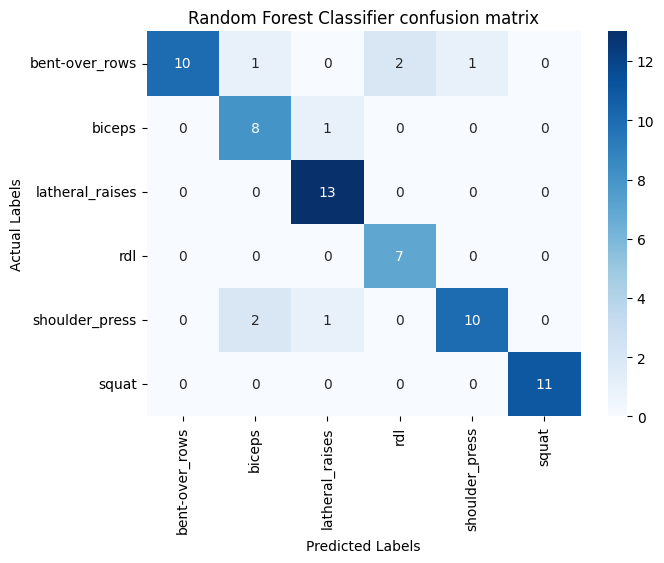

In [10]:
cm=confusion_matrix(Y_test,y_pred )

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=input_files, yticklabels=input_files)
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Random Forest Classifier confusion matrix')
plt.show()